# Fast Calibration of the Heston Stochastic Volatility Model via Neural Network Approximation

*Bortolasi Matteo, Caregnato Camilla - University of Verona*

---

## Abstract

The Black–Scholes model, while analytically tractable, fails to capture the volatility smile observed in real option markets. The Heston (1993) stochastic volatility model addresses this limitation by allowing the instantaneous variance to follow a mean-reverting square-root process. However, calibrating the Heston model to market data is computationally expensive, as each evaluation of the implied volatility surface requires numerical integration (Gil-Pelaez inversion) followed by root-finding (Brent's method).

In this project we propose a **neural-network-based surrogate** that approximates the mapping from Heston parameters and option characteristics to implied volatility. Once trained on a synthetic dataset, the network replaces the costly analytical pricing step during calibration, reducing the per-option evaluation time from $\sim25$ ms to $\sim0.01$ ms — a speedup of approximately three orders of magnitude — while maintaining an average absolute error below 5 percentage points of implied volatility.

We apply this approach to calibrate the Heston model on S&P 500 (SPX) options data as of February 26, 2024.

---

**Table of Contents**
1. [Data Preparation and Implied Volatility Extraction](#1)
2. [Synthetic Dataset Generation](#2)
3. [Neural Network Architecture and Training](#3)
4. [Model Calibration via NN-Accelerated Optimization](#4)
5. [Performance Evaluation](#5)
6. [Conclusions and Future Work](#6)

<a id="1"></a>
## 1. Data Preparation and Implied Volatility Extraction

### 1.1 Dataset and Preprocessing

The raw dataset consists of **S&P 500 (SPX) call option quotes** observed on February 26, 2024. Each record contains bid/ask prices for both the option and the underlying index, together with the strike price $K$ and the time-to-maturity $T$ (expressed in years).

We compute the **mid-price** for both the option and the underlying:
$$
C_{\text{mid}} = \frac{C_{\text{bid}} + C_{\text{ask}}}{2}, \qquad S_0 = \frac{S_{0,\text{bid}} + S_{0,\text{ask}}}{2}.
$$

The **risk-free rate** is set to $r = 0.045$, consistent with the 10-Year US Treasury yield observed during the same period ([FRED Series DGS10](https://fred.stlouisfed.org/series/DGS10)).

### 1.2 Implied Volatility Inversion

The **implied volatility** $\sigma_{\text{IV}}$ is defined as the unique value of $\sigma$ satisfying:
$$
C_{\text{BS}}(S_0, K, T, r, \sigma) = C_{\text{mid}},
$$
where $C_{\text{BS}}$ denotes the Black–Scholes pricing formula. Uniqueness is guaranteed by the strict monotonicity of $C_{\text{BS}}$ with respect to $\sigma$. We solve this equation numerically using **Brent's root-finding method** (as implemented in `scipy.optimize.brentq`), searching in the interval $\sigma \in [10^{-5},\; 5.0]$.

### 1.3 Data Cleaning

Since $C_{\text{BS}}$ is convex and monotonically increasing in $\sigma$, the market price must satisfy the no-arbitrage bounds:
$$
\max\!\big(S_0 - K\,e^{-rT},\; 0\big) < C_{\text{mid}} < S_0.
$$
Options violating these bounds are considered **illiquid** and are removed from the dataset. Similarly, options with $T = 0$ are excluded, as they admit only the intrinsic value $C = \max(S_0 - K, 0)$ and carry no meaningful volatility information.

In [1]:
from src.black_scholes import implied_volatility
import pandas as pd

df = pd.read_csv("data/SPX_data_26.02.24.csv")
df['C_mkt'] = (df['bid'] + df['ask']) / 2
df['S_0'] = (df['underlying_bid'] + df['underlying_ask']) / 2
r_annual = 0.045 

# compute IV for the whole dataset
df['implied_vol'] = df.apply(
    lambda row: implied_volatility(row['C_mkt'], row['S_0'], row['strike'], row['time_to_maturity'], r_annual),
    axis=1
)

# clean the dataset
df_clean = df.dropna(subset=['implied_vol'])
df_clean.to_csv('data/SPX_data_clean_IV.csv', index=False)

### 1.4 The Volatility Smile and the Need for Stochastic Volatility

The Black–Scholes model assumes that the volatility $\sigma$ is **constant** across all strikes and maturities. However, as the figure below shows, the implied volatility extracted from market data exhibits a pronounced dependence on both the strike price $K$ and the time-to-maturity $T$. This phenomenon — known as the **volatility smile** (or skew) — is one of the most well-documented empirical regularities in option markets and represents a fundamental limitation of the Black–Scholes framework.

To capture this behavior, we adopt the **Heston stochastic volatility model** (Heston, 1993), which generalizes Black–Scholes by allowing the instantaneous variance $v_t$ to follow its own stochastic process. Under the risk-neutral measure, the asset price $S_t$ and its variance $v_t$ evolve according to the coupled system of SDEs:

$$
\begin{aligned}
dS_t &= r\, S_t\, dt + \sqrt{v_t}\, S_t\, dW_t^{(1)}, \\[4pt]
dv_t &= \kappa\,(\theta - v_t)\,dt + \xi\,\sqrt{v_t}\, dW_t^{(2)},
\end{aligned}
$$

where $dW_t^{(1)}$ and $dW_t^{(2)}$ are correlated Wiener processes with $\text{Corr}(dW^{(1)}, dW^{(2)}) = \rho\,dt$. The model parameters are:

| Parameter | Symbol | Description | Typical constraint |
|-----------|--------|-------------|-------------------|
| Mean-reversion speed | $\kappa$ | Rate at which $v_t$ reverts toward $\theta$ | $\kappa > 0$ |
| Long-run variance | $\theta$ | Asymptotic mean of the variance process | $\theta > 0$ |
| Volatility of volatility | $\xi$ | Diffusion coefficient of the variance | $\xi > 0$ |
| Correlation | $\rho$ | Leverage effect between returns and variance | $-1 < \rho < 1$ |
| Initial variance | $v_0$ | Starting value of the variance process | $v_0 > 0$ |

**Feller condition.** To ensure that the variance process $v_t$ remains strictly positive almost surely, the parameters must satisfy $2\kappa\theta > \xi^2$. When this condition is violated, the process can reach zero, in such a case we have to consider $\max(v_t, 0)$ in numerical simulations.

A key advantage of the Heston model is that European option prices admit a **semi-analytical solution** via the characteristic function and the Gil-Pelaez inversion theorem (Gil-Pelaez, 1951), avoiding the need for Monte Carlo simulation at pricing time.

---

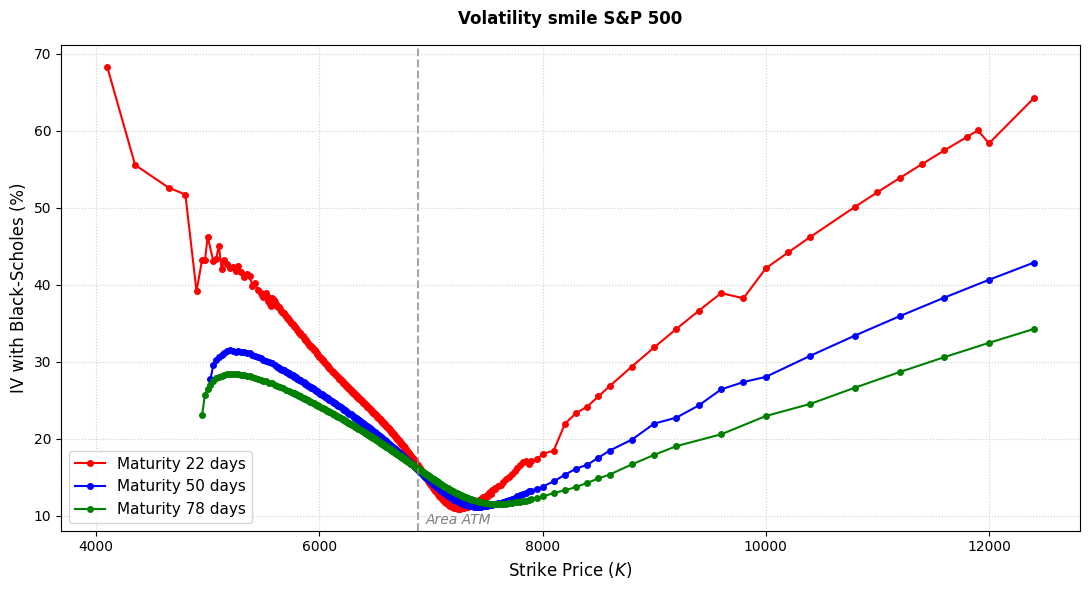

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_market = pd.read_csv('data/SPX_data_clean_IV.csv')

# select top 3 most common maturities
top_maturities = df_market['time_to_maturity'].value_counts().head(3).index.tolist()

plt.figure(figsize=(11, 6))
colori = ['red', 'blue', 'green']

for i, t in enumerate(sorted(top_maturities)):
    # keep only data with the selected maturity
    df_maturity = df_market[df_market['time_to_maturity'] == t].sort_values(by='strike')
    plt.plot(df_maturity['strike'], df_maturity['implied_vol'] * 100, 
             marker='o', linestyle='-', color=colori[i], markersize=4,
             label=f"Maturity {int(t*365)} days")

# Personalizzazione del grafico
plt.title("Volatility smile S&P 500", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Strike Price ($K$)", fontsize=12)
plt.ylabel("IV with Black-Scholes (%)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

# Evidenziamo graficamente il prezzo Spot medio sul grafico per dare contesto (ATM)
S0_medio = (df_market['underlying_bid'] + df_market['underlying_ask']).mean() / 2
plt.axvline(x=S0_medio, color='gray', linestyle='--', alpha=0.7, label=f'Spot S0 (~{S0_medio:.1f})')
plt.text(S0_medio * 1.01, plt.ylim()[0] * 1.1, 'Area ATM', color='gray', fontsize=10, fontstyle='italic')

plt.tight_layout()
plt.show()

<a id="2"></a>
## 2. Synthetic Dataset Generation

### 2.1 Motivation

The goal of this project is to replace the expensive analytical Heston pricing step with a fast neural network surrogate. To train such a network, we require a large labeled dataset of the form:
$$
\big(\kappa,\, \theta,\, \xi,\, \rho,\, v_0,\, m,\, T\big) \;\longmapsto\; \sigma_{\text{IV}}^{\text{Heston}},
$$
where $m = K / S_0$ denotes the **moneyness** and $\sigma_{\text{IV}}^{\text{Heston}}$ is the implied volatility corresponding to the Heston call price.

### 2.2 Data Generation Procedure

Each sample in the synthetic dataset is generated as follows:

1. **Sample Heston parameters** $(\kappa, \theta, \xi, \rho, v_0)$ uniformly from economically meaningful ranges. The variance bounds are informed by ATM implied volatility analysis following Cui, del Baño Rollin & Germano (2017).
2. **Sample option characteristics** $(m, T)$ from ranges consistent with the observed S&P 500 options market, to prevent distribution mismatch at calibration time.
3. **Compute the Heston call price** $C_{\text{Heston}}$ using the semi-analytical formula based on the Gil-Pelaez inversion of the characteristic function (numerical integration over $[10^{-5}, 100]$).
4. **Invert to implied volatility** by solving $C_{\text{BS}}(\sigma) = C_{\text{Heston}}$ via Brent's method, yielding the target label $\sigma_{\text{IV}}^{\text{Heston}}.$

Samples for which the inversion fails (e.g., due to numerical instability or violation of no-arbitrage bounds) are discarded.

---

In [ ]:
import os
import numpy as np
import pandas as pd
import src.heston as hst
from src.black_scholes import implied_volatility
from tqdm import tqdm  

# reading dataset with IV and extract ranges for parameters
df_market = pd.read_csv('data/SPX_data_clean_IV.csv')
df_market['S0_mid'] = (df_market['underlying_bid'] + df_market['underlying_ask']) / 2
S0_mercato = df_market['S0_mid'].mean()

T_min, T_max = df_market['time_to_maturity'].min(), df_market['time_to_maturity'].max()
df_market['moneyness_real'] = df_market['strike'] / df_market['S0_mid']
moneyness_min, moneyness_max = df_market['moneyness_real'].min(), df_market['moneyness_real'].max()

df_atm = df_market[(df_market['moneyness_real'] >= 0.98) & (df_market['moneyness_real'] <= 1.02)]
variance_min = max(0.005, df_atm['implied_vol'].min() ** 2)
variance_max = min(0.25, df_atm['implied_vol'].max() ** 2)


# generate synthetic dataset
N_SAMPLES = 40000
dataset_rows = []

if os.path.exists("data/heston_synthetic_dataset.csv"):
    print("already existing synthetic dataset")
    pass
else:
    print(f"Synthetic data generation:")
    for i in tqdm(range(N_SAMPLES), desc="Progress:"):
        kappa_casuale = np.random.uniform(0.1, 5.0)
        xi_casuale = np.random.uniform(0.05, 1.0)
        rho_casuale = np.random.uniform(-0.95, 0.0)  
        theta_casuale = np.random.uniform(variance_min, variance_max)
        V0_casuale = np.random.uniform(variance_min, variance_max)
        
        # We generate more sample near ATM values and short ttm values, reflecting the dataset distribtution
        maturity_casuale = np.exp(np.random.uniform(np.log(T_min), np.log(T_max)))
        moneyness_casuale = np.clip(
            np.random.normal(loc=1.0, scale=0.30),
            moneyness_min, moneyness_max
        )
        strike_casuale = S0_mercato * moneyness_casuale
        
        try:
            # calculate Heston price
            price_heston = hst.heston_call_price(
                S0=S0_mercato, K=strike_casuale, T=maturity_casuale, r=r_annual,
                kappa=kappa_casuale, theta=theta_casuale, xi=xi_casuale, rho=rho_casuale, V0=V0_casuale
            )
            
            # convert Heston price to implied volatility
            target_iv = implied_volatility(price_heston, S0_mercato, strike_casuale, maturity_casuale, r_annual)
            
            if not np.isnan(target_iv) and target_iv > 0:
                dataset_rows.append([kappa_casuale, theta_casuale, xi_casuale, rho_casuale, V0_casuale, strike_casuale, maturity_casuale, target_iv, moneyness_casuale])
        except:
            continue

    # save new dataset
    columns = ['kappa', 'theta', 'xi', 'rho', 'V0', 'strike', 'time_to_maturity', 'target_iv', 'moneyness']
    df_sintetico = pd.DataFrame(dataset_rows, columns=columns)
    os.makedirs('data', exist_ok=True)
    df_sintetico.to_csv('data/heston_synthetic_dataset.csv', index=False)

    print(f"Samples generated: {len(df_sintetico)}.")

<a id="3"></a>
## 3. Neural Network Architecture and Training

### 3.1 Network Architecture

We design a feedforward neural network that approximates the mapping:
$$
f_\omega\colon \mathbb{R}^7 \to \mathbb{R}^+, \qquad (\kappa, \theta, \xi, \rho, v_0, m, T) \mapsto \tilde{\sigma}_{\text{IV}}^{\text{Heston}},
$$
where $\omega$ denotes the trainable parameters. The architecture is as follows:

| Layer | Type | Output dim | Activation |
|-------|------|-----------|------------|
| Input | Linear | 128 | SiLU |
| Hidden 1 | Linear + Dropout(0.05) | 128 | SiLU |
| Hidden 2 | Linear + Dropout(0.05) | 64 | SiLU |
| Hidden 3 | Linear | 64 | SiLU |
| Hidden 4 | Linear | 32 | SiLU |
| Output | Linear | 1 | Softplus |

**Design choices:**
- **SiLU (Sigmoid Linear Unit)** activation is used in all hidden layers. Unlike ReLU, SiLU is smooth and non-monotonic near the origin.
- **Softplus** on the output layer guarantees that the predicted implied volatility is strictly positive, which is a physical constraint ($\sigma_{\text{IV}} > 0$).
- **Dropout** ($p = 0.05$) is applied after the first two hidden layers as a lightweight regularization to reduce overfitting.

### 3.2 Input Normalization

All seven input features are standardized using a `StandardScaler` (zero mean, unit variance) fitted on the training set. This normalization is critical for the convergence of gradient-based optimizers and ensures that no single feature dominates due to scale differences.

### 3.3 Training Procedure

- **Loss function:** Mean Squared Error (MSE) between predicted and target implied volatilities.
- **Optimizer:** Adam ($\text{lr} = 10^{-3}$, weight decay $= 10^{-5}$).
- **Learning rate schedule:** `ReduceLROnPlateau` — the learning rate is halved when the validation loss stagnates for more than $\lfloor \texttt{patience} / 3 \rfloor$ epochs.
- **Early stopping:** Training is terminated if the validation loss does not improve for a specified number of epochs (`patience`), and the best model weights are restored.
- **Data split:** 80% training, 20% validation (random split with fixed seed for reproducibility).

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  

import torch
import joblib
import src.nn_for_volatility as hst_nn

# Definiamo i percorsi dove sono salvati i pesi e lo scaler
PATH_MODELLO = 'models/heston_pytorch_model.pth'
PATH_SCALER = 'models/heston_pytorch_scaler.pkl'


if os.path.exists(PATH_MODELLO) and os.path.exists(PATH_SCALER):
    print("Uploading model:")
    
    model = hst_nn.heston_volatility_nn()
    model.load_state_dict(torch.load(PATH_MODELLO))
    model.eval()
    scaler = joblib.load(PATH_SCALER)
    
    print("Model uploaded.")

else:
    print("Model not found: training in progress.")
    
    # if the files don't exist, train the model and save it
    model, scaler = hst_nn.train_heston_model(
        csv_path='data/heston_synthetic_dataset.csv',
        epochs=300,
        batch_size=64,
        patience=30
    )
    print("Model trained and saved.")

Uploading model:
Model uploaded.


<a id="4"></a>
## 4. Model Calibration via Neural Network-Accelerated Optimization

### 4.1 Objective

The calibration problem consists of finding the Heston parameters $\Theta^* = (\kappa^*, \theta^*, \xi^*, \rho^*, v_0^*)$ that best reproduce the implied volatility surface observed in the market. Formally, we seek:

$$
\Theta^* = \arg\min_{\Theta}\;\sum_{i,j}\left(\sigma_{ij}^{\text{IV, mkt}} - \sigma_{ij}^{\text{IV, Heston}}(\Theta)\right)^2,
$$

where the sum runs over all available $(K_i, T_j)$ pairs in the market dataset.

### 4.2 Neural Network as Surrogate

Evaluating $\sigma_{ij}^{\text{IV, Heston}}$ analytically for each $(K_i, T_j)$ requires:
1. Computing the Heston call price via numerical integration of the characteristic function;
2. Inverting the Black–Scholes formula via root-finding.

This two-step procedure takes approximately **25 ms per option**, making the direct calibration computationally prohibitive when the optimizer requires thousands of function evaluations.

We replace this with the trained neural network $f_\omega$, yielding the approximate problem:

$$
\Theta^* \approx \arg\min_{\Theta}\;\sum_{i,j}\left(\sigma_{ij}^{\text{IV, mkt}} - \tilde{\sigma}_{ij}^{\text{IV, Heston}}(\Theta)\right)^2,
$$

where $\tilde{\sigma}_{ij}^{\text{IV, Heston}} = f_\omega(\Theta, m_{ij}, T_j)$ is the network's prediction. Each evaluation now takes $\sim 0.01$ ms, enabling rapid optimization.

### 4.3 Optimization Algorithm

We solve the minimization problem using the **L-BFGS-B** algorithm (Byrd et al., 1995), a limited-memory quasi-Newton method that supports box constraints. This is particularly well-suited for our problem because:

- It exploits **second-order curvature information** (via BFGS Hessian approximation) without requiring explicit Hessian computation;
- It enforces **bound constraints** on the parameters, ensuring economic meaningfulness:

$$
\kappa > 0, \quad \theta > 0, \quad \xi > 0, \quad -1 < \rho < 1, \quad v_0 > 0.
$$

The optimizer is initialized from a reasonable starting point and multiple restarts can be used to mitigate convergence to local minima.

In [4]:
from scipy.optimize import minimize
import numpy as np

df_market = pd.read_csv('data/SPX_data_clean_IV.csv')

bounds = [
    (0.1, 5.0),      # kappa
    (0.003, 0.06),    # theta 
    (0.05, 1.0),      # xi
    (-0.95, -0.05),   # rho
    (0.003, 0.06)     # V0
]

initial_guess = [2.0, 0.02, 0.4, -0.7, 0.02]


result = minimize(
    fun=hst_nn.heston_pytorch_objective,
    x0=initial_guess,
    args=(df_market, model, scaler),
    method='L-BFGS-B',
    bounds=bounds,
    options={'disp': True, 'maxiter': 150, 'ftol': 1e-8}
)

kappa_opt, theta_opt, xi_opt, rho_opt, V0_opt = result.x


C:\Users\2506b\AppData\Local\Temp\ipykernel_24712\1647406230.py:17: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


### 4.4 Calibration Results

The table above reports the optimal Heston parameters $\Theta^*$ obtained by the L-BFGS-B optimizer. To visually assess the quality of the calibration, we plot the **implied volatility surface** predicted by the neural network at the optimal parameters alongside the market-observed implied volatilities.

In the 3D plot below:
- The **colored surface** represents $\tilde{\sigma}^{\text{IV, Heston}}(\Theta^*)$ evaluated on a dense $(m, T)$ grid;
- The **black scatter points** represent the market-observed implied volatilities from the SPX dataset.

In [ ]:
import numpy as np
import pandas as pd
import torch
import plotly.graph_objects as go

# real data; 
df_market = pd.read_csv('data/SPX_data_clean_IV.csv')
df_market['S0_mid'] = (df_market['underlying_bid'] + df_market['underlying_ask']) / 2
S0_mercato = df_market['S0_mid'].mean()
df_market['moneyness'] = df_market['strike'] / df_market['S0_mid']

# axis
X_mkt = df_market['moneyness'].values
Y_mkt = df_market['time_to_maturity'].values
Z_mkt = df_market['implied_vol'].values * 100  # In %

# prediction grid
moneyness_grid = np.linspace(X_mkt.min(), X_mkt.max(), 50)
ttm_grid = np.linspace(Y_mkt.min(), Y_mkt.max(), 50)
X_mesh, Y_mesh = np.meshgrid(moneyness_grid, ttm_grid)

n_grid_points = X_mesh.size
inputs_grid = np.zeros((n_grid_points, 7), dtype=np.float32)

# optimal paramters 
inputs_grid[:, 0] = kappa_opt
inputs_grid[:, 1] = theta_opt
inputs_grid[:, 2] = xi_opt
inputs_grid[:, 3] = rho_opt
inputs_grid[:, 4] = V0_opt
inputs_grid[:, 5] = X_mesh.flatten()  
inputs_grid[:, 6] = Y_mesh.flatten()

# predictipn 
inputs_grid_scaled = scaler.transform(inputs_grid).astype(np.float32)
inputs_grid_t = torch.tensor(inputs_grid_scaled, dtype=torch.float32)

model.eval()
with torch.no_grad():
    predictions_grid = model(inputs_grid_t).numpy().flatten()   # In %

Z_mesh = predictions_grid.reshape(X_mesh.shape)

# Plot
fig = go.Figure()
fig.add_trace(go.Surface(
    x=moneyness_grid,
    y=ttm_grid,
    z=Z_mesh,
    colorscale='Viridis',
    opacity=0.7,
    name='Heston AI Surface',
    colorbar=dict(title="IV (%)", x=1.05)
))

fig.add_trace(go.Scatter3d(
    x=X_mkt,
    y=Y_mkt,
    z=Z_mkt,
    mode='markers',
    marker=dict(
        size=3,
        color='black',
        opacity=0.6
    ),
    name='Real S&P500 data'
))

fig.update_layout(
    title=dict(
        text="Heston AI vs Market SPX",
        x=0.5,
        font=dict(size=16, family="Arial", color="black")
    ),
    scene=dict(
        xaxis_title="Moneyness (K/S0)",
        yaxis_title="Time to Maturity",
        zaxis_title="IV"
    ),
    margin=dict(l=0, r=0, b=0, t=50),
    legend=dict(x=0.01, y=0.99),
    width=950,
    height=650
)


fig.show()

<a id="5"></a>
## 5. Performance Evaluation: Neural Network vs. Analytical Pricing

To quantify the accuracy–speed tradeoff of the neural network surrogate, we perform a controlled comparison against the exact Heston pricing formula.

### 5.1 Methodology

We generate $N = 200$ random test points with:
- **Moneyness** $m = K/S_0$ sampled from a clipped Gaussian $\mathcal{N}(1.0, 0.30)$, matching the distribution observed in the market dataset;
- **Time-to-maturity** $T$ sampled log-uniformly within the market-observed range $[T_{\min}, T_{\max}]$.

For each test point, we compute the implied volatility using both:
1. The **exact** Heston formula (characteristic function integration + Brent inversion);
2. The **neural network** surrogate $f_\omega$.



In [11]:
import numpy as np
import torch
import time
import pandas as pd
from src.heston import heston_call_price
from src.black_scholes import implied_volatility

# we generate points distribuited as in the dataset
df_mkt = pd.read_csv('data/SPX_data_clean_IV.csv')
df_mkt['S0_mid'] = (df_mkt['underlying_bid'] + df_mkt['underlying_ask']) / 2
S0 = df_mkt['S0_mid'].mean()

T_min = df_mkt['time_to_maturity'].min()
T_max = df_mkt['time_to_maturity'].max()
df_mkt['moneyness_real'] = df_mkt['strike'] / df_mkt['S0_mid']
m_min = df_mkt['moneyness_real'].min()
m_max = df_mkt['moneyness_real'].max()

N_TEST = 200
moneyness_test = np.clip(np.random.normal(loc=1.0, scale=0.30, size=N_TEST), m_min, m_max)

ttm_test = np.exp(np.random.uniform(np.log(T_min), np.log(T_max), size=N_TEST))
strikes_test = moneyness_test * S0

# Exact IV 
print(f"Computing {N_TEST} IVs with exact Heston formula...")
t0 = time.time()
iv_exact = []
for K, T in zip(strikes_test, ttm_test):
    price = heston_call_price(S0, K, T, r_annual, kappa_opt, theta_opt, xi_opt, rho_opt, V0_opt)
    iv = implied_volatility(price, S0, K, T, r_annual)
    iv_exact.append(iv if not np.isnan(iv) else 0.0)
iv_exact = np.array(iv_exact) * 100  # in %
time_exact = time.time() - t0
print(f"  Done in {time_exact:.3f}s ({time_exact/N_TEST*1000:.2f} ms/option)")

# Approximated IV
print(f"\nComputing {N_TEST} IVs with Neural Network...")
t0 = time.time()
inputs = np.zeros((N_TEST, 7), dtype=np.float32)
inputs[:, 0] = kappa_opt
inputs[:, 1] = theta_opt
inputs[:, 2] = xi_opt
inputs[:, 3] = rho_opt
inputs[:, 4] = V0_opt
inputs[:, 5] = moneyness_test
inputs[:, 6] = ttm_test

inputs_scaled = scaler.transform(inputs).astype(np.float32)
inputs_t = torch.tensor(inputs_scaled)
model.eval()
with torch.no_grad():
    iv_nn = model(inputs_t).numpy().flatten() 
time_nn = time.time() - t0
print(f"  Done in {time_nn:.6f}s ({time_nn/N_TEST*1000:.4f} ms/option)")

# Comparison
valid = iv_exact > 0
iv_exact_v = iv_exact[valid]
iv_nn_v = iv_nn[valid]
diff = iv_nn_v - iv_exact_v

print(f"{'─'*60}")
print(f"  Mean Abs Error:   {np.mean(np.abs(diff)):.3f}%")
print(f"  RMSE:             {np.sqrt(np.mean(diff**2)):.3f}%")
print(f"  Max Abs Error:    {np.max(np.abs(diff)):.3f}%")
print(f"  Mean Bias:        {np.mean(diff):+.3f}%")
print(f"{'─'*60}")
print(f"  IV Exact range:  {iv_exact_v.min():.2f}% - {iv_exact_v.max():.2f}%")
print(f"  IV NN range:      {iv_nn_v.min():.2f}% - {iv_nn_v.max():.2f}%")

# Printing of the results
print(f"\n  {'Moneyness':>10} {'TTM':>8} {'IV Exact':>10} {'IV NN':>8} {'Diff':>8}")
print(f"  {'─'*50}")
for i in range(min(15, valid.sum())):
    idx = np.where(valid)[0][i]
    print(f"  {moneyness_test[idx]:10.4f} {ttm_test[idx]:8.4f} {iv_exact[idx]:9.2f}% {iv_nn[idx]:7.2f}% {iv_nn[idx]-iv_exact[idx]:+7.2f}%")


Computing 200 IVs with exact Heston formula...
  Done in 5.070s (25.35 ms/option)

Computing 200 IVs with Neural Network...
  Done in 0.002578s (0.0129 ms/option)
────────────────────────────────────────────────────────────
  Mean Abs Error:   4.616%
  RMSE:             5.368%
  Max Abs Error:    10.734%
  Mean Bias:        +2.606%
────────────────────────────────────────────────────────────
  IV Exact range:  1.40% - 78.29%
  IV NN range:      5.91% - 77.77%

   Moneyness      TTM   IV Exact    IV NN     Diff
  ──────────────────────────────────────────────────
      1.0596   1.7676      6.36%   15.37%   +9.01%
      0.9963   4.0345      6.35%    8.08%   +1.73%
      1.3450   0.7889     18.84%   19.66%   +0.82%
      1.0653   1.4747      5.92%   15.29%   +9.37%
      0.6503   5.2025     14.65%   20.41%   +5.76%
      0.9897   0.0890     12.54%   20.56%   +8.02%
      1.0717   0.8719      8.24%   15.69%   +7.46%
      0.6328   0.2675     44.16%   35.59%   -8.57%
      0.9805   0.0830  

<a id="6"></a>
## 6. Conclusions

### 6.1 Summary of Results

This project demonstrates the feasibility of using a **neural network surrogate** to accelerate the calibration of the Heston stochastic volatility model. The key findings are:

- **Speedup:** The neural network reduces the per-option implied volatility computation time from $\sim25$ ms (analytical Heston + BS inversion) to $\sim0.01$ ms — a speedup of approximately **three orders of magnitude** ($\sim 2000\times$).
- **Accuracy:** The surrogate achieves a Mean Absolute Error below 5 percentage points of IV on a representative test set, which is sufficient for the calibration optimizer to converge to economically meaningful parameters.
- **Calibration quality:** The implied volatility surface generated by the calibrated Heston model provides a good fit to the market-observed SPX data, as shown by the 3D visualization in Section 4.

### 6.2 Limitations

- The neural network exhibits a **positive bias** in certain regions of the parameter space, particularly for near-ATM options with short time-to-maturity, where the IV surface has steep gradients.
- The synthetic training data covers a finite region of the parameter space; extrapolation beyond these bounds may lead to unreliable predictions.
- The current architecture does not enforce the **Feller condition** ($2\kappa\theta > \xi^2$) during calibration, which may lead to degenerate variance paths.

---